In [130]:
import pandas as pd 
import numpy as np

### Step 1. Data Collection and initial Exploration

In [131]:
df = pd.read_csv("IMDB Dataset.csv")

In [132]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


#### Dataset Overview

In [133]:
df.shape

(50000, 2)

In [134]:
print(df.columns)

Index(['review', 'sentiment'], dtype='object')


#### Dataset Information

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [136]:
# stastical summary 

df.describe(include='all')

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


#### check null values

In [137]:
print("Null Values:\n")
print(df.isnull().sum())

Null Values:

review       0
sentiment    0
dtype: int64


In [138]:
# there is no null values so we don't have to handlethem.

In [139]:
# check duplicate rows
duplicate_rows = df.duplicated().sum()

print("Duplicate Rows:", duplicate_rows)

Duplicate Rows: 418


In [140]:
# remove duplicate rows

df = df.drop_duplicates()

print("dataset shape after removing duplicates")

dataset shape after removing duplicates


In [141]:
# check sentiment distribution
print("Sentiment Distribution:\n")
print(df["sentiment"].value_counts())

Sentiment Distribution:

sentiment
positive    24884
negative    24698
Name: count, dtype: int64


In [142]:
# final dataset shape

print("Final Dataset Shape:", df.shape)

Final Dataset Shape: (49582, 2)


#### Data preprocessing

##### Import Libraries

In [143]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [144]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer

In [145]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\saini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\saini\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\saini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [146]:
# making copy of review colunmn


df["clean_review"] = df["review"]

df[["review", "clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,One of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,A wonderful little production. <br /><br />The...
2,I thought this was a wonderful way to spend ti...,I thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,Basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...","Petter Mattei's ""Love in the Time of Money"" is..."


In [147]:
# Remove HTML tags

def remove_html(text):
    return re.sub(r"<.*?>", "", text)
    
df["clean_review"] = df["clean_review"].apply(remove_html)

df["clean_review"].head()

0    One of the other reviewers has mentioned that ...
1    A wonderful little production. The filming tec...
2    I thought this was a wonderful way to spend ti...
3    Basically there's a family where a little boy ...
4    Petter Mattei's "Love in the Time of Money" is...
Name: clean_review, dtype: object

In [148]:
# remove urls

def remove_urls(text):
    return re.sub(r"http\S+|www\S|https\S+", "", text)

df["clean_review"] = df["clean_review"].apply(remove_urls)

df["clean_review"].head()

0    One of the other reviewers has mentioned that ...
1    A wonderful little production. The filming tec...
2    I thought this was a wonderful way to spend ti...
3    Basically there's a family where a little boy ...
4    Petter Mattei's "Love in the Time of Money" is...
Name: clean_review, dtype: object

In [149]:
# convert text into lowercase

df["clean_review"] = df["clean_review"].str.lower()

In [150]:
df["clean_review"].head()

0    one of the other reviewers has mentioned that ...
1    a wonderful little production. the filming tec...
2    i thought this was a wonderful way to spend ti...
3    basically there's a family where a little boy ...
4    petter mattei's "love in the time of money" is...
Name: clean_review, dtype: object

In [151]:
# remove punctuation

def remove_punctuation(text):
    return text.translate(str.maketrans("", "", string.punctuation))

df["clean_review"] = df["clean_review"].apply(remove_punctuation)


In [152]:
# remove special characters and numbers

def remove_special_characters(text):
    return re.sub(r"[^a-zA-Z\s]", "", text)

df["clean_review"] = df["clean_review"].apply(remove_special_characters)

In [153]:
# remove extra spaces

def remove_extra_spaces(text):
    return re.sub(r"\s+", " ", text).strip()

df["clean_review"] = df["clean_review"].apply(remove_extra_spaces)

##### Now Tokenization

In [154]:
df["tokens"] = df["clean_review"].apply(word_tokenize)

df[["clean_review", "tokens"]].head()

,clean_review,tokens
0,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione..."
1,a wonderful little production the filming tech...,"[a, wonderful, little, production, the, filmin..."
2,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,..."
3,basically theres a family where a little boy j...,"[basically, theres, a, family, where, a, littl..."
4,petter matteis love in the time of money is a ...,"[petter, matteis, love, in, the, time, of, mon..."


##### remove stopwords

In [155]:
stop_words = set(stopwords.words("english"))

df["tokens"] = df["tokens"].apply(
    lambda words : [word for word in words if word not in stop_words]
)

df["tokens"].head()

0    [one, reviewers, mentioned, watching, oz, epis...
1    [wonderful, little, production, filming, techn...
2    [thought, wonderful, way, spend, time, hot, su...
3    [basically, theres, family, little, boy, jake,...
4    [petter, matteis, love, time, money, visually,...
Name: tokens, dtype: object

##### Perform stemming

In [156]:
stemmer = PorterStemmer()

df["tokens"] = df["tokens"].apply(
    lambda words: [stemmer.stem(word) for word in words]
)

df["tokens"].head()

0    [one, review, mention, watch, oz, episod, youl...
1    [wonder, littl, product, film, techniqu, unass...
2    [thought, wonder, way, spend, time, hot, summe...
3    [basic, there, famili, littl, boy, jake, think...
4    [petter, mattei, love, time, money, visual, st...
Name: tokens, dtype: object

In [157]:
# convert tokens back to sentence

df["clean_review"] = df["tokens"].apply(lambda words: " ".join(words))

df[["review", "clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one review mention watch oz episod youll hook ...
1,A wonderful little production. <br /><br />The...,wonder littl product film techniqu unassum old...
2,I thought this was a wonderful way to spend ti...,thought wonder way spend time hot summer weeke...
3,Basically there's a family where a little boy ...,basic there famili littl boy jake think there ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visual stun film...


#### Label encoding of sentiment column

In [158]:
encoder = LabelEncoder()

df["sentiment"] = encoder.fit_transform(df["sentiment"])

df["sentiment"].value_counts()

sentiment
1    24884
0    24698
Name: count, dtype: int64

##### bag of words

In [159]:
bow = CountVectorizer(max_features=5000)
X = bow.fit_transform(df["clean_review"])

y = df["sentiment"]

print("shape of BOW matrix:", X.shape)


shape of BOW matrix: (49582, 5000)


#### Train Test Split

In [160]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (39665, 5000)
Testing Data Shape: (9917, 5000)


In [161]:
from sklearn.linear_model import LogisticRegression

In [162]:
model = LogisticRegression(max_iter=1000)

In [163]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [164]:
y_pred = model.predict(X_test)

#### Accuracy

In [165]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8663910456791368


In [166]:
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 86.64%


#### Confusion Matrix

In [167]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4226  713]
 [ 612 4366]]


#### Confusion Matrix Visualization

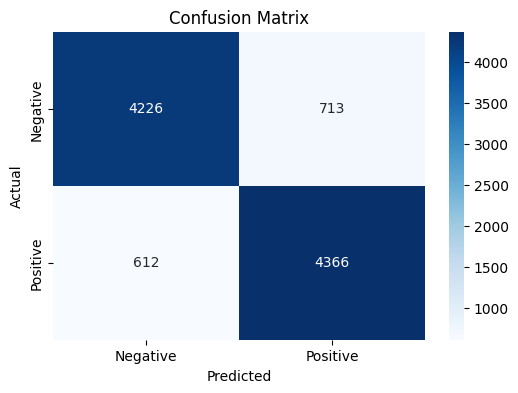

In [168]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Negative","Positive"],
            yticklabels=["Negative","Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [169]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.86      0.86      4939
           1       0.86      0.88      0.87      4978

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



#### predicting my own review


In [170]:
review = ["This movie was amazing. I really enjoyed it."]

In [171]:
review = [remove_html(review[0])]
review = [remove_urls(review[0])]
review = [review[0].lower()]
review = [remove_punctuation(review[0])]
review = [remove_special_characters(review[0])]
review = [remove_extra_spaces(review[0])]

words = word_tokenize(review[0])
words = [word for word in words if word not in stop_words]
words = [stemmer.stem(word) for word in words]

review = [" ".join(words)]

In [172]:
review_bow = bow.transform(review)

In [173]:
prediction = model.predict(review_bow)

if prediction[0] == 1:
    print("Positive Review 😊")
else:
    print("Negative Review 😞")

Positive Review 😊
